In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau  # 导入用于计算 tau 和 p_value 的函数
import os
import glob
import pandas as pd
import numpy as np
from itertools import product
from huggingface_hub import HfApi, snapshot_download
from google.colab import userdata
# ==========================================
# 1. Hugging Face 配置 (替代 Drive 挂载)
# ==========================================
HF_TOKEN = userdata.get('HF_TOKEN') # 请确保 Colab Secret 中有 HF_TOKEN
REPO_ID = "JONESMITH007/DFL"        # 你的仓库 ID
LOCAL_ROOT = "./intensity_transformer_final"    # 本地缓存路径a

# 注意：根据你之前的上传逻辑，结果存储在仓库的这个子文件夹下
REPO_SUBFOLDER = "FL_Experiments/intensity_transformer_final"
SAVE_DIR = os.path.join(LOCAL_ROOT, REPO_SUBFOLDER)

os.makedirs(SAVE_DIR, exist_ok=True)

# --- 同步远程数据到本地 ---
print("🔄 正在从 Hugging Face 同步数据...")
snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    local_dir=LOCAL_ROOT,
    allow_patterns=["**/intensity_Transformer*.csv"], # 下载所有 CNN 相关的 CSV
    token=HF_TOKEN
)
# ==========================================
# 6. 分析 FedAvg 文件的 final_asr 与 theo_intensity 的相关性 (Kendall Tau)
# ==========================================
print(f"\n{'='*40}")
print(f"{'='*40}")

# 匹配所有包含 FedAvg 的文件
fedavg_pattern = os.path.join(SAVE_DIR, "intensity_Transformer*.csv")
fedavg_files = glob.glob(fedavg_pattern)

if not fedavg_files:
    print("\n❌ 未找到任何 FedAvg 相关的 CSV 文件进行相关性分析。")
else:
    print(f"✅ 发现 {len(fedavg_files)} 个 FedAvg 文件，正在提取所有节点数据...\n")

    correlation_results = []
    all_fedavg_nodes = [] # 保存所有文件的数据以供后续汇总绘图

    for f in fedavg_files:
        df = pd.read_csv(f)

        # 1. 保留所有节点（不过滤 MAL 节点）
        df_target = df.copy()

        # 2. 确保目标列为数值类型 (防止字符导致报错)
        df_target['final_asr'] = pd.to_numeric(df_target['final_asr'], errors='coerce')
        df_target['theo_intensity'] = pd.to_numeric(df_target['theo_intensity'], errors='coerce')

        # 3. 去除可能存在的空值
        df_target = df_target.dropna(subset=['final_asr', 'theo_intensity'])

        if len(df_target) > 1: # 至少需要2个点才能算相关性
            # 4. 提取该文件对应的实验参数
            topo = df_target['topology'].iloc[0] if 'topology' in df_target.columns else "Unknown"
            mr = df_target['malicious_ratio'].iloc[0] if 'malicious_ratio' in df_target.columns else "Unknown"
            seed = df_target['seed'].iloc[0] if 'seed' in df_target.columns else "Unknown"

            # 5. 使用 scipy 计算 Kendall Tau 系数和 p 值
            tau, p_value = kendalltau(df_target['final_asr'], df_target['theo_intensity'])

            # 6. 记录结果
            correlation_results.append({
                'File': os.path.basename(f),
                'Topology': topo,
                'Mal_Ratio': mr,
                'Seed': seed,
                'Nodes_Count': len(df_target),
                'Kendall_Tau': tau,
                'P_Value': p_value,
                'Is_Significant': 'Yes' if p_value < 0.05 else 'No'
            })

            all_fedavg_nodes.append(df_target)



🔄 正在从 Hugging Face 同步数据...


Fetching ... files: 0it [00:00, ?it/s]


✅ 发现 19 个 FedAvg 文件，正在提取所有节点数据...



In [ ]:
# --- 补充：展示详细相关性表格 ---
if correlation_results:
    df_results = pd.DataFrame(correlation_results)

    # 按照相关性从高到低排序
    df_results = df_results.sort_values(by='Kendall_Tau', ascending=False)

    print("\n📊 每个文件的相关性分析明细 (Sorted by Tau):")
    print(df_results[['Topology', 'Mal_Ratio', 'Seed', 'Kendall_Tau', 'P_Value', 'Is_Significant']].to_markdown(index=False))

    # --- 补充：计算全局统计量 ---
    avg_tau = df_results['Kendall_Tau'].mean()
    significant_count = (df_results['P_Value'] < 0.05).sum()
    total_count = len(df_results)

    print(f"\n{'*'*40}")
    print(f"📈 全局分析总结:")
    print(f"平均 Kendall Tau 系数: {avg_tau:.4f}")
    print(f"显著性比例 (P < 0.05): {significant_count}/{total_count} ({significant_count/total_count:.1%})")
    print(f"{'*'*40}")


📊 每个文件的相关性分析明细 (Sorted by Tau):
| Topology   |   Mal_Ratio |   Seed |   Kendall_Tau |     P_Value | Is_Significant   |
|:-----------|------------:|-------:|--------------:|------------:|:-----------------|
| scale_free |         0.3 |      2 |      0.770098 | 2.75361e-06 | Yes              |
| scale_free |         0.3 |      2 |      0.769233 | 2.45489e-06 | Yes              |
| scale_free |         0.3 |      2 |      0.73069  | 8.26764e-06 | Yes              |
| scale_free |         0.3 |      2 |      0.727314 | 9.5144e-06  | Yes              |
| scale_free |         0.3 |      0 |      0.722958 | 8.69935e-06 | Yes              |
| scale_free |         0.3 |      0 |      0.677576 | 3.98737e-05 | Yes              |
| scale_free |         0.3 |      2 |      0.620356 | 0.000158882 | Yes              |
| scale_free |         0.3 |      1 |      0.603183 | 0.000213445 | Yes              |
| scale_free |         0.3 |      0 |      0.577614 | 0.000437536 | Yes              |
| scale_fr

In [ ]:
fedavg_files

['./intensity_transformer_final/FL_Experiments/intensity_transformer_final/intensity_Transformer_scale_free_MR0.3_INTENSITY0.02_norm_factor3_FedAvg_seed1.csv',
 './intensity_transformer_final/FL_Experiments/intensity_transformer_final/intensity_Transformer_scale_free_MR0.3_INTENSITY0.02_norm_factor10_FedAvg_seed1.csv',
 './intensity_transformer_final/FL_Experiments/intensity_transformer_final/intensity_Transformer_scale_free_MR0.3_INTENSITY0.02_norm_factor1_FedAvg_seed1.csv',
 './intensity_transformer_final/FL_Experiments/intensity_transformer_final/intensity_Transformer_scale_free_MR0.3_INTENSITY0.02_norm_factor5_FedAvg_seed2.csv',
 './intensity_transformer_final/FL_Experiments/intensity_transformer_final/intensity_Transformer_scale_free_MR0.3_INTENSITY0.02_norm_factor8_FedAvg_seed0.csv',
 './intensity_transformer_final/FL_Experiments/intensity_transformer_final/intensity_Transformer_scale_free_MR0.3_INTENSITY0.02_norm_factor3_FedAvg_seed0.csv',
 './intensity_transformer_final/FL_Expe

找到 3 个符合条件的文件，正在按强度排名进行聚合...


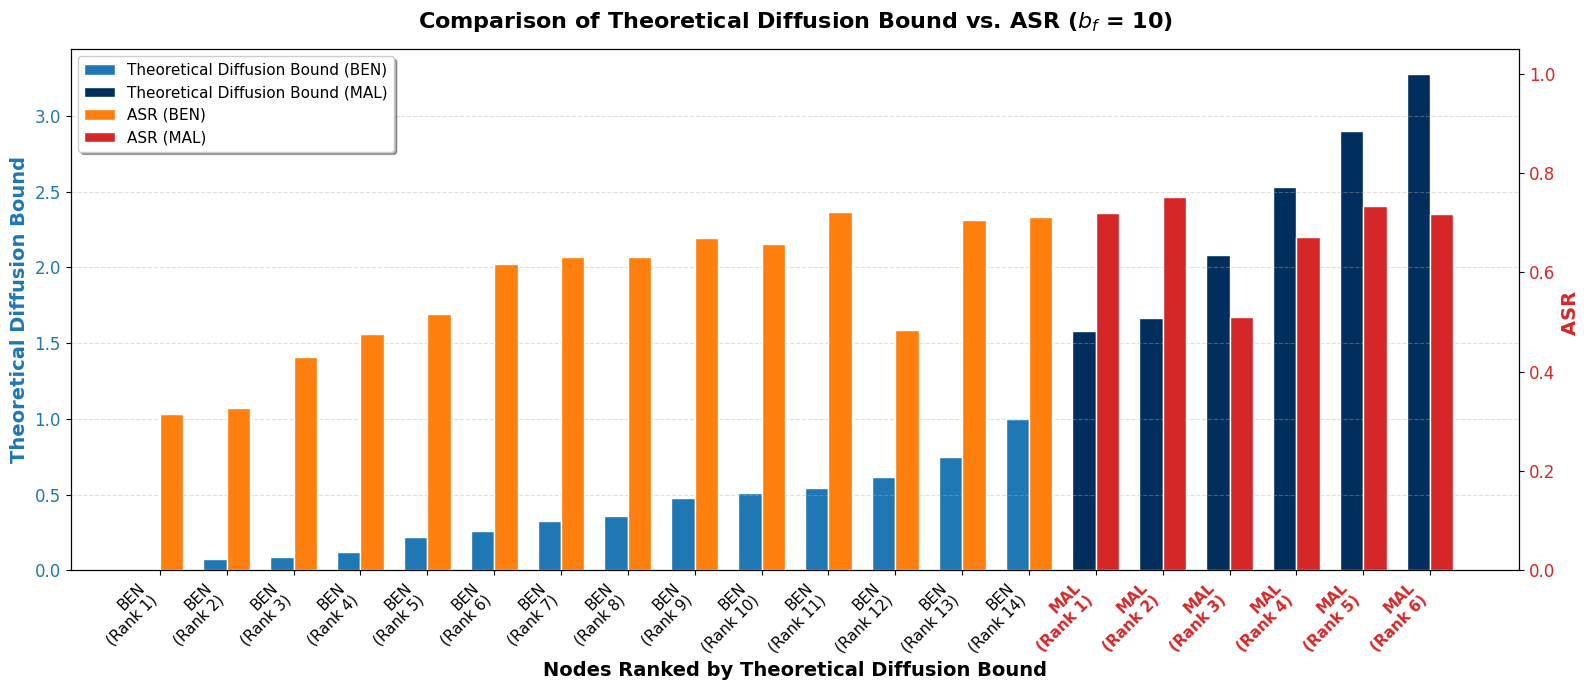

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ==========================================
# 0. 批量读取并提取数据
# ==========================================
TARGET_NORM_FACTOR = 10
TARGET_MECH = "FedAvg"
FOLDER_PATH = './intensity_transformer_final/FL_Experiments/intensity_transformer_final'

file_pattern = os.path.join(FOLDER_PATH, f"*norm_factor{TARGET_NORM_FACTOR}_*.csv")
csv_files = glob.glob(file_pattern)

print(f"找到 {len(csv_files)} 个符合条件的文件，正在按强度排名进行聚合...")

df_list = [pd.read_csv(f) for f in csv_files]
df_all = pd.concat(df_list, ignore_index=True)

# ==========================================
# 1. 🌟 核心：按组别与理论强度排名求平均
# ==========================================
# 确保数据里有 seed 列（如果没有，可以用 df_all['source_file'] 代替作为分组依据）
if 'seed' not in df_all.columns:
    # 如果没保存 seed 列，这里手动给每个文件的数据打上一个递增的实验批次号
    df_all['seed'] = np.repeat(np.arange(len(csv_files)), len(df_list[0]))

# 在每个 seed 和 node_type 内部，按照 theo_intensity 进行排名
# method='first' 保证即便强度相同，也会被赋予不重复的递增排名 (1, 2, 3...)
df_all['intensity_rank'] = df_all.groupby(['seed', 'node_type'])['theo_intensity'].rank(method='first')

# 按节点身份 (BEN/MAL) 和 它的强度排名 (intensity_rank) 进行求均值
df_avg = df_all.groupby(['node_type', 'intensity_rank']).agg({
    'theo_intensity': 'mean',
    'final_asr': 'mean',
    'final_acc': 'mean'
}).reset_index()

# 转换为百分比
df_avg['final_asr'] = df_avg['final_asr']
df_avg['final_acc'] = df_avg['final_acc']

# 排序：最终画图前，按平均后的 theo_intensity 从小到大整体排序
df_avg = df_avg.sort_values(by='theo_intensity').reset_index(drop=True)

# 创建虚拟的 X 轴标签（不再使用真实的 client_id，而是用 身份+排名，例如 "BEN\n(R1)"）
df_avg['client_label'] = df_avg['node_type'] + '\n(Rank ' + df_avg['intensity_rank'].astype(int).astype(str) + ')'

# 为良性节点和恶意节点分配不同的颜色
colors_theo = ['#1F77B4' if nt != 'MAL' else '#002E5D' for nt in df_avg['node_type']]
colors_asr  = ['#FF7F0E' if nt != 'MAL' else '#D62728' for nt in df_avg['node_type']]

# ==========================================
# 2. 绘图部分 (逻辑与之前完全一致)
# ==========================================
x = np.arange(len(df_avg))
width = 0.35

fig, ax1 = plt.subplots(figsize=(16, 7))

# --- 左轴：理论强度 (柱状图) ---
rects1 = ax1.bar(x - width/2, df_avg['theo_intensity'], width, color=colors_theo, edgecolor='white')
ax1.set_ylabel('Theoretical Diffusion Bound', color='#1F77B4', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1F77B4', labelsize=12)
ax1.set_xlabel('Nodes Ranked by Theoretical Diffusion Bound', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_avg['client_label'], fontsize=11, rotation=45, ha='right')

# 高亮 MAL 文本
for text in ax1.get_xticklabels():
    if 'MAL' in text.get_text():
        text.set_color('#D62728')
        text.set_fontweight('bold')

ax1.grid(True, axis='y', linestyle='--', alpha=0.4)

# --- 右轴：ASR (柱状图) ---
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, df_avg['final_asr'], width, color=colors_asr, edgecolor='white')

asr_max = df_avg['final_asr'].max()
is_percentage = asr_max > 1.5
ax2.set_ylabel(f'ASR {"(%)" if is_percentage else ""}', color='#D62728', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#D62728', labelsize=12)
ax2.set_ylim(0, 105 if is_percentage else 1.05)

# --- 图例美化 ---
legend_elements = [
    Patch(facecolor='#1F77B4', edgecolor='w', label='Theoretical Diffusion Bound (BEN)'),
    Patch(facecolor='#002E5D', edgecolor='w', label='Theoretical Diffusion Bound (MAL)'),
    Patch(facecolor='#FF7F0E', edgecolor='w', label='ASR (BEN)'),
    Patch(facecolor='#D62728', edgecolor='w', label='ASR (MAL)')
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=11, frameon=True, shadow=True)

# 使用 fr"" 前缀：f 代表格式化变量，r 代表原始字符串（防止反斜杠转义）
plt.title(fr'Comparison of Theoretical Diffusion Bound vs. ASR ($b_f$ = {TARGET_NORM_FACTOR})',
          fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [ ]:
df

,seed,mechanism,malicious_ratio,defense_ratio,topology,start_time,duration_sec,client_id,final_acc,final_asr,theo_intensity,node_type,neighbors,client_label
0,1,MAB,0.3,0,scale_free,2026-03-15 17:08:14,300.4,13,71.499997,0.632911,0.000000,BEN,"[0, 5, 17]",C13\n(BEN)
1,1,MAB,0.3,0,scale_free,2026-03-15 17:08:14,300.4,7,72.000003,0.632911,0.041435,BEN,"[0, 5]",C7\n(BEN)
2,1,MAB,0.3,0,scale_free,2026-03-15 17:08:14,300.4,17,70.899999,1.265823,0.072228,BEN,"[0, 13, 19]",C17\n(BEN)
3,1,MAB,0.3,0,scale_free,2026-03-15 17:08:14,300.4,5,72.500002,0.632911,0.129130,BEN,"[3, 4, 7, 11, 12, 13]",C5\n(BEN)
4,1,MAB,0.3,0,scale_free,2026-03-15 17:08:14,300.4,12,72.200000,0.632911,0.263735,BEN,"[3, 5, 15]",C12\n(BEN)
5,1,MAB,0.3,0,scale_free,2026-03-15 17:08:14,300.4,11,72.299999,0.632911,0.329170,BEN,"[3, 5]",C11\n(BEN)
6,1,MAB,0.3,0,scale_free,2026-03-15 17:08:14,300.4,15,72.100002,0.632911,0.370137,BEN,"[3, 12]",C15\n(BEN)
7,1,MAB,0.3,0,scale_free,2026-03-15 17:08:14,300.4,4,72.000003,0.632911,0.408886,BEN,"[0, 3, 5, 8, 16]",C4\n(BEN)
8,1,MAB,0.3,0,scale_free,2026-03-15 17:08:14,300.4,18,71.799999,1.265823,0.434142,BEN,"[8, 3]",C18\n(BEN)
9,1,MAB,0.3,0,scale_free,2026-03-15 17:08:14,300.4,8,71.899998,1.265823,0.474038,BEN,"[3, 4, 16, 18]",C8\n(BEN)


正在从 Hugging Face 获取实验数据...


Fetching ... files: 0it [00:00, ?it/s]

成功找到 18 个实验记录文件。

聚合后的相变数据：
   norm_factor  final_asr  final_acc
0            1   2.426160  72.600000
1            3  20.991561  73.026190
2            5  35.247137  72.183334
3            8  47.694394  72.088095
4           10  56.344183  70.828572
5           15  66.937914  69.673809


/tmp/ipykernel_842/83008334.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_benign['final_asr'] = df_benign['final_asr']*100
/tmp/ipykernel_842/83008334.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_benign['final_acc'] = df_benign['final_acc']*100


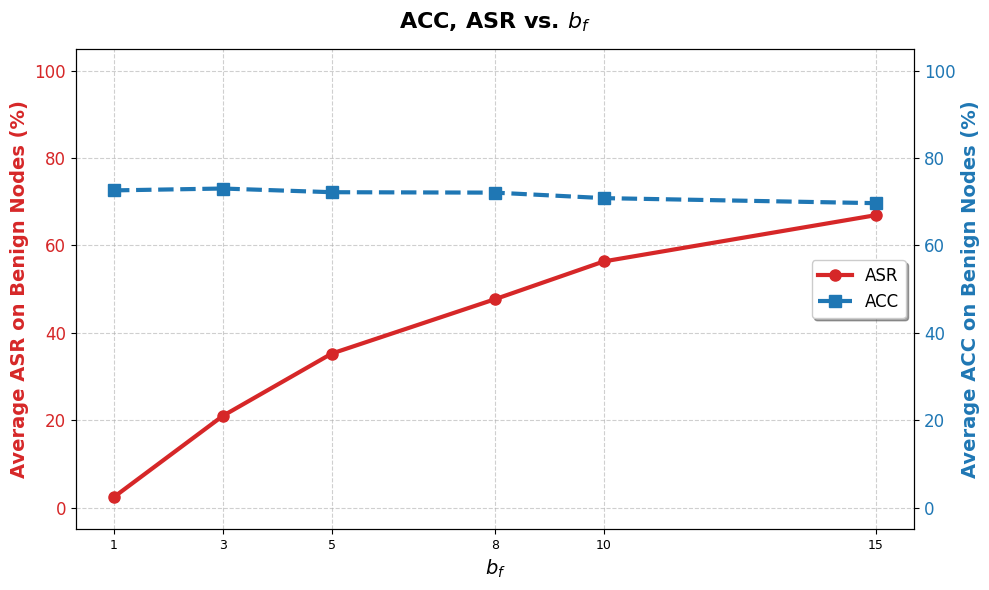

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import snapshot_download
from google.colab import userdata

# ==========================================
# 1. 从 Hugging Face 拉取实验结果
# ==========================================
print("正在从 Hugging Face 获取实验数据...")
HF_TOKEN = userdata.get('HF_TOKEN')
REPO_ID = "JONESMITH007/DFL"
FOLDER_PATH = "FL_Experiments/intensity_transformer_final"

# 下载指定文件夹下的所有 csv 文件到本地缓存
local_dir = snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    allow_patterns=f"{FOLDER_PATH}/*.csv",
    token=HF_TOKEN
)

# 获取所有下载的 CSV 文件路径
csv_files = glob.glob(os.path.join(local_dir, FOLDER_PATH, "*.csv"))
print(f"成功找到 {len(csv_files)} 个实验记录文件。")

# ==========================================
# 2. 数据整合与处理
# ==========================================
# 读取并合并所有 DataFrame
df_list = [pd.read_csv(f) for f in csv_files]
df_all = pd.concat(df_list, ignore_index=True)

# 🌟 核心：我们主要关注后门在“良性节点(BEN)”中的扩散情况
# 恶意节点(MAL)的 ASR 通常本来就是 100%，会干扰全局相变的观察
df_benign = df_all[df_all['node_type'] == 'BEN']
df_benign['final_asr'] = df_benign['final_asr']*100
df_benign['final_acc'] = df_benign['final_acc']*100
# 按 norm_factor 分组，计算平均 ASR 和平均 ACC
df_phase = df_benign.groupby('norm_factor')[['final_asr', 'final_acc']].mean().reset_index()
# 确保按 norm_factor 从小到大排序
df_phase = df_phase.sort_values(by='norm_factor').reset_index(drop=True)

print("\n聚合后的相变数据：")
print(df_phase)

# ==========================================
# 3. 绘制相变曲线 (双 Y 轴折线图)
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- X 轴设置 ---
# 因为 norm_factor 的取值跨度较大 (0.01, 0.1, 0.5, 1, 3)，
# 如果点挤在一起，可以取消下面这行的注释，启用对数坐标轴：
#ax1.set_xscale('log')
ax1.set_xlabel(fr'$b_f$', fontsize=14, fontweight='bold')
ax1.set_xticks(df_phase['norm_factor'])
ax1.set_xticklabels(df_phase['norm_factor'], fontsize=9)

# --- 左轴：ASR (红色粗线) ---
color_asr = '#D62728'
ax1.set_ylabel('Average ASR on Benign Nodes (%)', color=color_asr, fontsize=14, fontweight='bold')
line1 = ax1.plot(df_phase['norm_factor'], df_phase['final_asr'],
                 color=color_asr, marker='o', linewidth=3, markersize=8, label='ASR')
ax1.tick_params(axis='y', labelcolor=color_asr, labelsize=12)
ax1.set_ylim(-5, 105) # 纵坐标固定 0-100%

# 添加网格线
ax1.grid(True, linestyle='--', alpha=0.6)

# --- 右轴：ACC (蓝色虚线) ---
ax2 = ax1.twinx()
color_acc = '#1F77B4'
ax2.set_ylabel('Average ACC on Benign Nodes (%)', color=color_acc, fontsize=14, fontweight='bold')
line2 = ax2.plot(df_phase['norm_factor'], df_phase['final_acc'],
                 color=color_acc, marker='s', linestyle='--', linewidth=3, markersize=8, label='ACC')
ax2.tick_params(axis='y', labelcolor=color_acc, labelsize=12)
ax2.set_ylim(-5, 105)

# --- 图例与标题 ---
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=12, frameon=True, shadow=True)

plt.title(fr'ACC, ASR vs. $b_f$', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()